In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Questions 1 and 2

In [2]:
def generate_sketching_matrix_F(k, m):
    # Generate a random m x m orthogonal matrix
    Q, _ = np.linalg.qr(np.random.randn(m, m))
    # Take the first k rows and scale
    F = Q[:k, :] * np.sqrt(m / k)  # F is k x m
    return F

def generate_random_matrix_A(m, n):
    t = 10  # Number of singular values in each group
    num_groups = int(np.ceil(n / t))
    r = (1e-10) ** (1 / (num_groups - 1)) if num_groups > 1 else 1e-10

    # Generate singular values
    singular_values = []
    for j in range(num_groups):
        value = r ** j
        count = t if (len(singular_values) + t) <= n else n - len(singular_values)
        singular_values.extend([value] * count)
    true_sigma_i = np.array(singular_values)

    # Ensure the length of singular_values is n
    assert len(true_sigma_i) == n, "The length of singular values should be n."

    # Generate random orthogonal matrices U and V_T
    U, _ = np.linalg.qr(np.random.randn(m, n))
    V, _ = np.linalg.qr(np.random.randn(n, n))

    # Create the diagonal matrix Sigma
    Sigma = np.diag(true_sigma_i)
    
    # Construct the matrix A
    A = U @ Sigma @ V.T

    # Return A and the true singular values
    return A, true_sigma_i



## Question 3

In [18]:
plots = {}
for n in [50, 500]:
        for m in [2 * n, 10 * n]:
            if m >= 5000:
                break
            # Generate A and true_sigma_i
            A, true_sigma_i = generate_random_matrix_A(m, n)
            for k in [int(0.1 * n), int(0.5 * n)]:
                # Initialize a dictionary to collect ratios per unique singular value
                print(f"{m} {n} {k}")
                unique_true_sigma_i = np.unique(true_sigma_i)
                ratio_dict = {sigma: [] for sigma in unique_true_sigma_i}

                for _ in range(20):
                    F = generate_sketching_matrix_F(k, m)
                    # Compute singular values of FA
                    sketched_sigma_i = np.linalg.svd(F @ A, compute_uv=False)
                    # Match lengths
                    min_len = min(len(sketched_sigma_i), len(true_sigma_i))
                    # Compute ratios
                    ratios_current = sketched_sigma_i[:min_len] / true_sigma_i[:min_len]
                    # Store ratios in the dictionary
                    for idx in range(min_len):
                        sigma = true_sigma_i[idx]
                        ratio = ratios_current[idx]
                        ratio_dict[sigma].append(ratio)

                # Prepare data for plotting
                data_to_plot = []
                positions = []
                for sigma in sorted(unique_true_sigma_i, reverse=True):
                    data_to_plot.append(ratio_dict[sigma])
                    positions.append(sigma)
                plots[(m,n,k)] = (data_to_plot,positions)

                                               

False
100 50 5
100 50 25
False
500 50 5
500 50 25
False
1000 500 50
1000 500 250
True


In [25]:
def plot(plots, m,n,k):
    # Plotting
    print(f"{m=} {n=} {k=}")
    plt.figure(figsize=(10, 6))
    data_to_plot,positions = plots[(m,n,k)]
    plt.boxplot(data_to_plot, positions=positions, vert=False)
    plt.xscale('log')
    plt.xlabel('Ratio of Sketched to True Singular Values')
    plt.ylabel('True Singular Values')
    plt.title(f'Whisker Plot (m={m}, n={n}, k={k})')
    plt.tight_layout()

    plt.tight_layout()
    plt.show()           

m=100 n=50 k=5


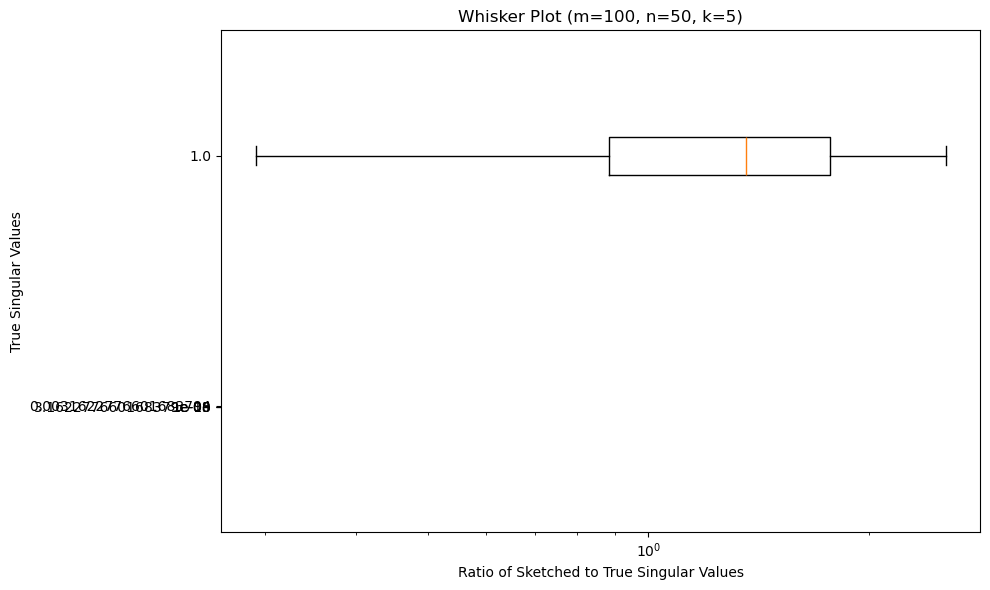

m=100 n=50 k=25


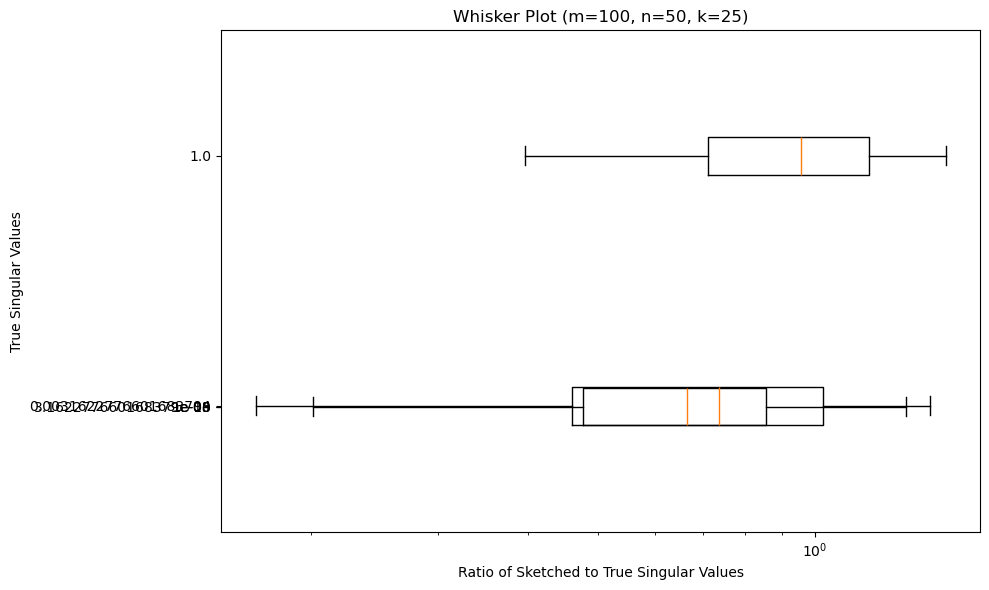

In [26]:
for k,v in list(plots.items())[:2]:
    plot(plots, *k)

m=500 n=50 k=5


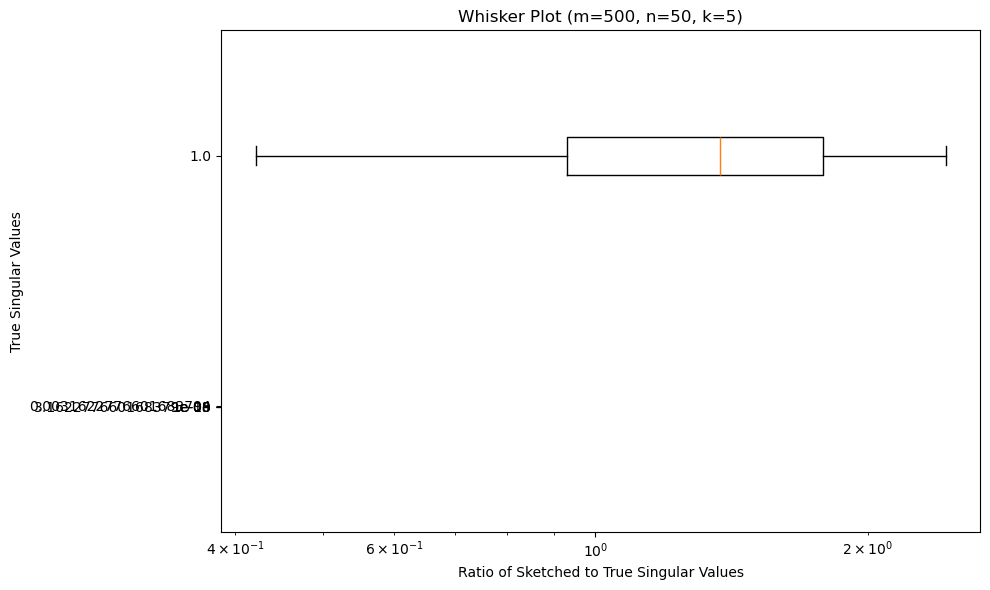

m=500 n=50 k=25


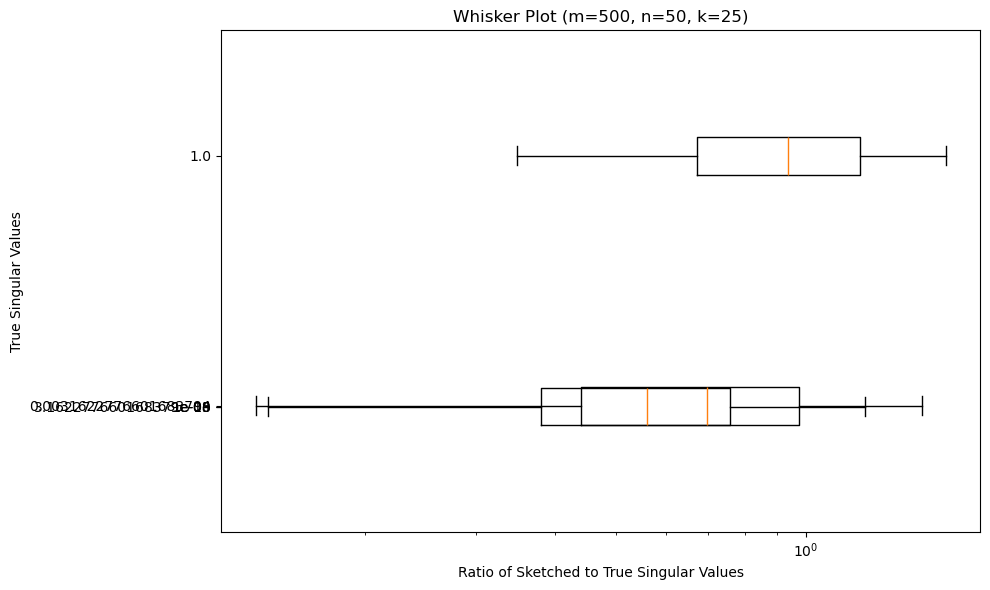

In [28]:
for k,v in list(plots.items())[2:4]:
    plot(plots, *k)

m=1000 n=500 k=50


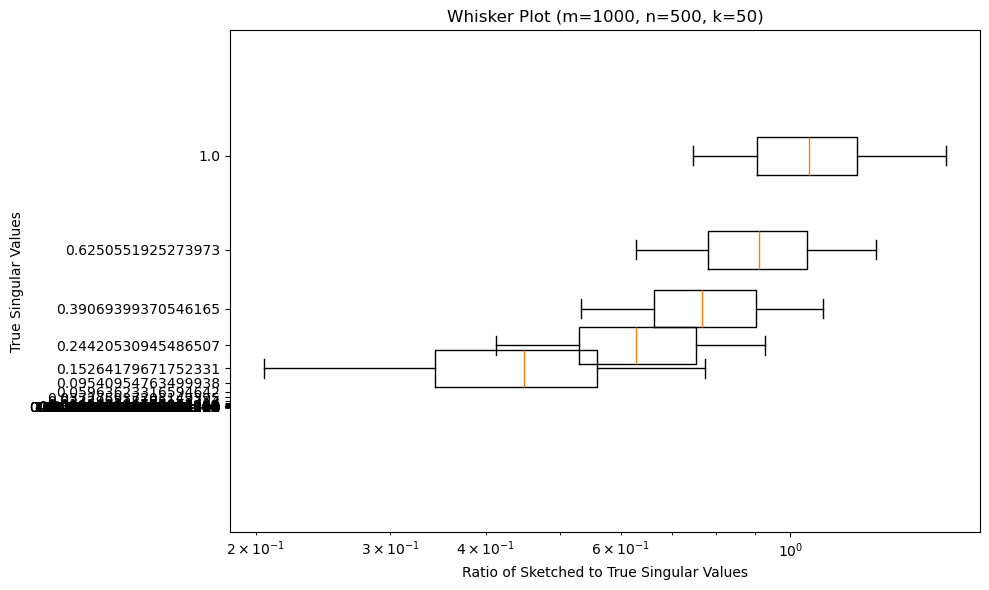

m=1000 n=500 k=250


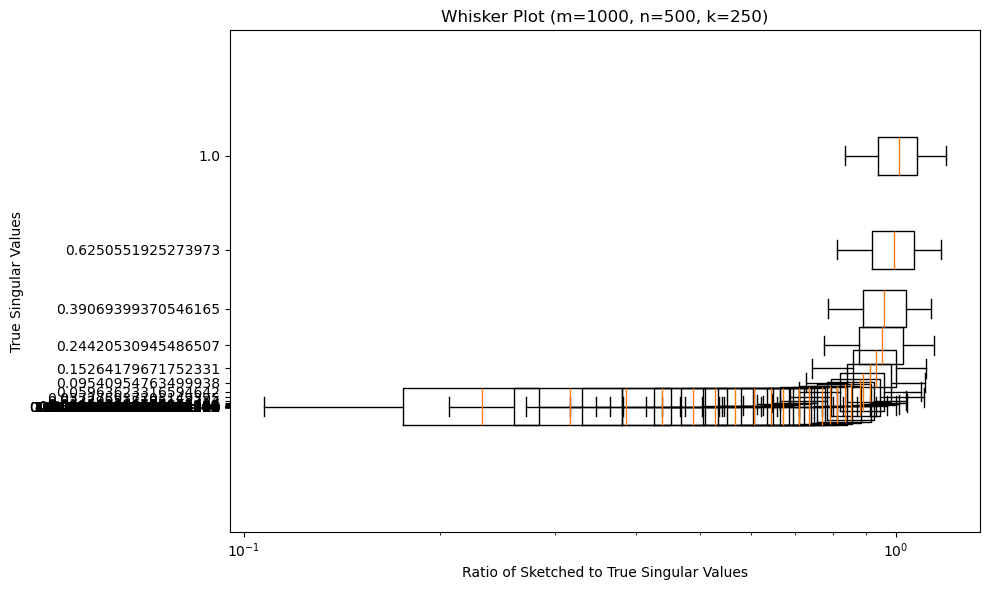

In [29]:
for k,v in list(plots.items())[4:6]:
    plot(plots, *k)

## Question 4

When n is small there isn't a strong curve drawn, but as k increases the medians of the box plots are very concentrated around 1 which implies that the approximation is very close. as n m and k increase the approximation becomes exponentially more accurate and k has the most influence